# M2 — NKC field inventory

Loads the outputs of [`src/data/parse_nkc.py`](../src/data/parse_nkc.py) and answers:

1. How big is the Czech-translation subset?
2. What's the coverage of `240 $a` (original-language title) — the field CLAUDE.md flags as critical for Goodreads matching when no OCLC is present?
3. What's the source-language mix and time distribution? Both feed M3/M4 planning.

Heavy logic (streaming the 9.9 GB MARC dump, applying the filter, writing CSV) lives in the script. This notebook only loads and visualises the artefacts.

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH = REPO / "data" / "interim" / "nkc_translations.csv"
REPORT_PATH = REPO / "reports" / "m2_nkc_inventory.json"

print("CSV:    ", CSV_PATH, "exists" if CSV_PATH.exists() else "MISSING")
print("Report: ", REPORT_PATH, "exists" if REPORT_PATH.exists() else "MISSING")

CSV:     /home/firstone/Bachelors-thesis/data/interim/nkc_translations.csv exists
Report:  /home/firstone/Bachelors-thesis/reports/m2_nkc_inventory.json exists


## Headline numbers

The filter is *strict* — see the `parse_nkc` module docstring. A record qualifies as a "Czech translation" only when an `041` field has `$a == cze` AND a `$h` value that's neither `cze` nor `und`.

In [8]:
with open(REPORT_PATH, encoding="utf-8") as f:
    report = json.load(f)

print(f"Total NKC records:          {report['total_records']:>10,}")
print(f"  with any 041 field:       {report['records_with_041']:>10,}")
print(f"  Czech translations kept:  {report['translation_records']:>10,}")
print(f"Filter rate:                {report['filter_rate']:>10.2%}")
print(f"Wall time:                  {report['elapsed_seconds']:>10.0f} s")

Total NKC records:           2,842,070
  with any 041 field:          583,678
  Czech translations kept:     225,483
Filter rate:                     7.93%
Wall time:                         530 s


## Field coverage on the translation subset

Coverage = fraction of kept records where the column is non-empty. Drives matching-strategy choices in M4.

- **`035_oclc`** is the single best cross-reference key to Goodreads. High coverage here is decisive.
- **`240_a_original_title`** is the fallback when OCLC is absent. CLAUDE.md warned this may be sparse.
- **`260_c` vs `264_c`**: 260 is the older (AACR2) form, 264 the newer (RDA) form — together they should approach 100%.

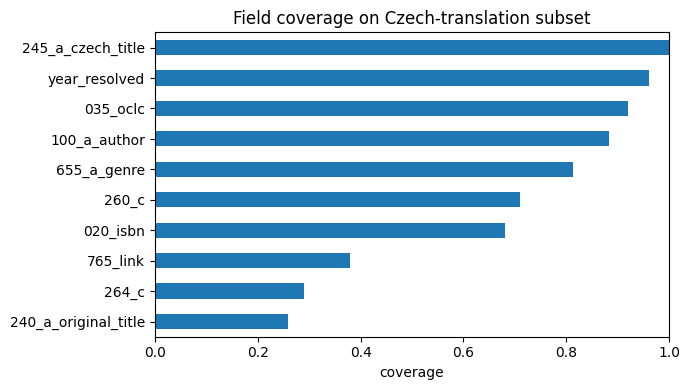

,coverage
245_a_czech_title,1.0000
year_resolved,0.9609
035_oclc,0.9194
100_a_author,0.8830
655_a_genre,0.8125
260_c,0.7107
020_isbn,0.6801
765_link,0.3793
264_c,0.2893
240_a_original_title,0.2589


In [9]:
coverage = report["field_coverage_on_translations"]
pd.Series(coverage).sort_values().plot.barh(figsize=(7, 4))
plt.xlim(0, 1)
plt.xlabel("coverage")
plt.title("Field coverage on Czech-translation subset")
plt.tight_layout()
plt.show()
pd.Series(coverage).sort_values(ascending=False).to_frame("coverage")

## Source languages

The `041 $h` distribution is also a model feature later — translations from English vs German vs Russian have very different bestseller dynamics in CZ.

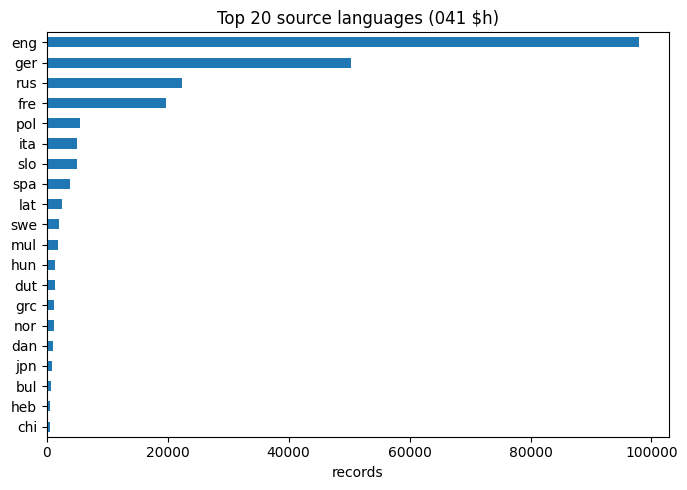

,records
eng,97967
ger,50249
rus,22288
fre,19702
pol,5584
ita,5076
slo,4966
spa,3833
lat,2592
swe,1972


In [10]:
langs = pd.Series(report["source_language_top20"])
langs.sort_values().plot.barh(figsize=(7, 5))
plt.xlabel("records")
plt.title("Top 20 source languages (041 $h)")
plt.tight_layout()
plt.show()
langs.to_frame("records")

## Publication year distribution

Czech publication year (`260 $c` / `264 $c`) is the temporal cutoff for features. SCKN charts start in 2003, so only translations from ~2003 onward can be labelled as bestsellers; pre-2003 translations contribute label-zero context but no positive signal.

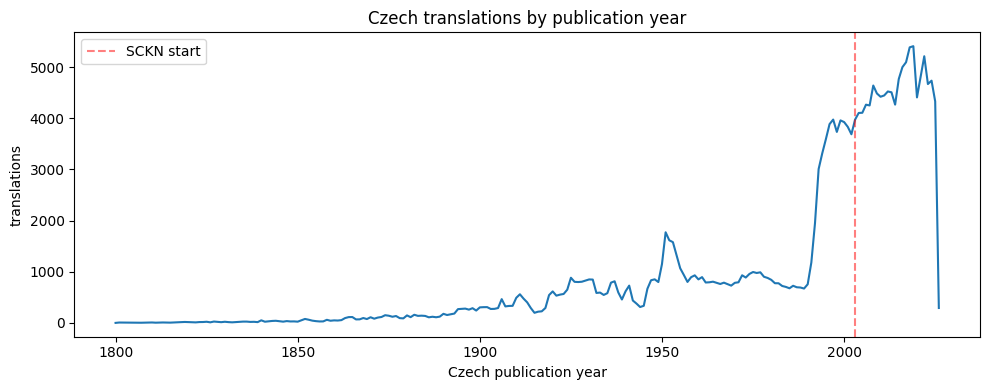

Translations published 2003+: 106,056 (48.9% of total)


In [11]:
years = pd.Series(
    {int(y): n for y, n in report["publication_year_distribution"].items()}
).sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
years.plot.line(ax=ax)
ax.axvline(2003, color="red", linestyle="--", alpha=0.5, label="SCKN start")
ax.set_xlabel("Czech publication year")
ax.set_ylabel("translations")
ax.set_title("Czech translations by publication year")
ax.legend()
plt.tight_layout()
plt.show()

post_sckn = years.loc[2003:].sum()
print(f"Translations published 2003+: {post_sckn:,} ({post_sckn / years.sum():.1%} of total)")

## Sample rows

Sanity check: do extracted fields look right?

In [12]:
df = pd.read_csv(CSV_PATH, dtype=str).fillna("")
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head()

Loaded 225,483 rows, 11 columns


,nkc_id,oclc,czech_isbn,czech_title,original_title,author,secondary_authors,czech_pub_year,source_lang,linked_records,genres
0,ck8300101,85541487,,O vzdělání lidu,,"Lunačarskij, Anatolij Vasil'jevič","Kyrášek, Jiří|Tuček, Alexandr",1982,rus,t:Direktivy VKP (b) i postanovlenija sovetskog...,výbory
1,ck8300109,39561173,,Metodická příručka k učebnici Chemie pro 7. ro...,,"Adamkovič, Emil","Berka, Ivan|Černá, Břetislava",1982,slo,t:Metodická príručka na vyučovanie chémie v 7....,metodické příručky
2,ck8300119,39561436,,Chemie pro 9. ročník zvláštní školy,,"Ďuriška, Augustín","Mandzjuk, Peter|Salamon, Zoltán|Jansa, Jaroslav",1982,slo,t:Chémia pre 9. ročník osobitných škol,učebnice základních škol
3,ck8300123,39561517,,Matematika pro 4. ročník zvláštní školy,,"Jakabová, Mária","Havlíčková, Iva|Legáthová, Anna|Ivaničová, Mária",1982,slo,t:Matematika pre 4. ročník osobitných škôl,učebnice základních škol
4,ck8300150,1378694800,,Zábavná matematika,,"Novoveský, Štefan","Križalkovič, Karol|Lečko, Imrich|Trefný, Zdeněk",1983,slo,,příručky|handbooks and manuals


## Coverage trend over time

The aggregate `240 $a` and `035 $a` numbers above hide a likely time effect: cataloguing standards changed over the decades, especially around the AACR2→RDA shift (~2013). What matters for us is coverage on **post-2003** records — that's the cohort SCKN actually labels.

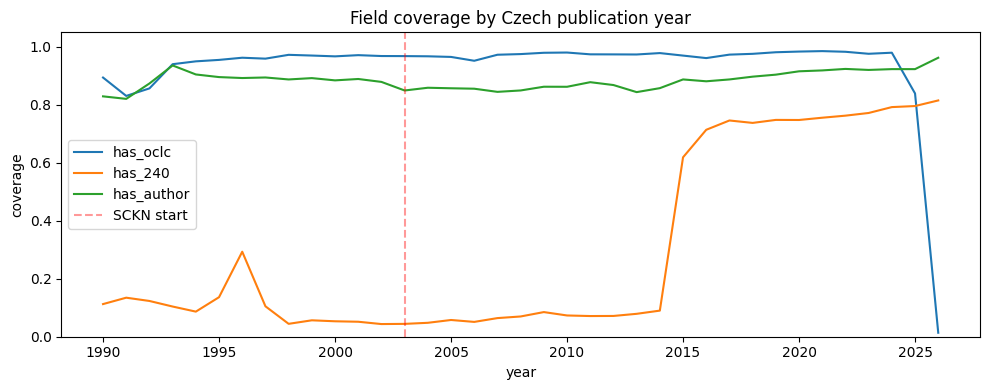

Coverage on the SCKN-labelable cohort (2003+):
  rows:        106,056
  has OCLC:    96.61%
  has 240 $a:  41.27%
  has author:  88.28%


In [13]:
yr = pd.to_numeric(df["czech_pub_year"], errors="coerce")
df_y = df.assign(year=yr).dropna(subset=["year"])
df_y["year"] = df_y["year"].astype(int)
df_y = df_y[df_y["year"].between(1990, 2026)]

coverage_by_year = df_y.groupby("year").agg(
    n=("nkc_id", "size"),
    has_oclc=("oclc", lambda s: (s != "").mean()),
    has_240=("original_title", lambda s: (s != "").mean()),
    has_author=("author", lambda s: (s != "").mean()),
)

fig, ax = plt.subplots(figsize=(10, 4))
coverage_by_year[["has_oclc", "has_240", "has_author"]].plot(ax=ax)
ax.axvline(2003, color="red", linestyle="--", alpha=0.4, label="SCKN start")
ax.set_ylim(0, 1.05)
ax.set_ylabel("coverage")
ax.set_title("Field coverage by Czech publication year")
ax.legend()
plt.tight_layout()
plt.show()

print("Coverage on the SCKN-labelable cohort (2003+):")
post = df_y[df_y["year"] >= 2003]
print(f"  rows:        {len(post):,}")
print(f"  has OCLC:    {(post['oclc'] != '').mean():.2%}")
print(f"  has 240 $a:  {(post['original_title'] != '').mean():.2%}")
print(f"  has author:  {(post['author'] != '').mean():.2%}")

## What's in records missing an author?

`100 $a` is empty in ~10% of records. Anthologies and edited compilations list the editor under `245 $c` (statement of responsibility), not `100`. M4 will need a fallback.

In [14]:
df[df["author"] == ""][["nkc_id", "czech_title", "original_title", "genres"]].head(10)

,nkc_id,czech_title,original_title,genres
9,ck8300215,Klinická onkologie,,monografie
35,ck8300367,Smích a písně Montmartru,,písně a humor
46,ck8300379,Maják na útesu Delfínů,,
47,ck8300380,Magický krystal,,
49,ck8300382,Pejskové a hafani,,ruské novely
57,ck8300391,Ráno pod Karpatami,,ukrajinská poezie|ukrajinské prózy|výbory
60,ck8300394,Nový tanec la-ba-da,,
64,ck8300469,Mé černé srdce,,literární pásma
80,ck8300532,Zkušenosti z vlastenecké a internacionální výc...,,sborníky
85,ck8300553,Problematika Malvínských ostrovů,,informační publikace
